# flexible neutrino oscillation simulator 

(c) Isabel Goos, Yael Deniz

15/07/2026



## loading packages

In [1]:
using Pkg
cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv" # 1D Earth/Mars/Moon models are defined

include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

using .commonBatchs, .planet1D, .GeoPoints

  Activating project at `~/Documents/Github/flexOPT`


In [2]:

Pkg.add("Plots")
Pkg.add("LaTeXStrings")
using Plots
using LaTeXStrings

   Resolving package versions...
     Project No packages added to or removed from `~/Documents/Github/flexOPT/Project.toml`
    Manifest No packages added to or removed from `~/Documents/Github/flexOPT/Manifest.toml`
   Resolving package versions...
    Updating `~/Documents/Github/flexOPT/Project.toml`
  [b964fa9f] + LaTeXStrings v1.4.0
    Manifest No packages added to or removed from `~/Documents/Github/flexOPT/Manifest.toml`


In [3]:
include("../src/neutrinoFlux.jl")
using .neutrinoFlux

## constants

In [15]:
numberEnergyBins = 100
numberAngleBins = 100
minEnergy = 1.0
maxEnergy = 100.0

100.0

## GeoPoints to make 

### here, i would like the users to decide which flux model to be used


## neutrino flux (completely new!!)


In [16]:
energies = logrange(minEnergy, maxEnergy, numberEnergyBins)
# read the neutrino-flux table nuflux.csv given in .../Neutrino-Flux/data
bin_centers, flux_νe_interp, flux_νμ_interp, flux_antiνe_interp, flux_antiνμ_interp, energies, flux_νe, flux_νμ, flux_antiνe, flux_antiνμ = read_neutrino_flux_table("nuflux", numberEnergyBins, numberAngleBins, false; data_dir="../dataInput/neutrinoFluxData/")


([1.023523326553919, 1.0722597633036501, 1.123345672533615, 1.1768322310338035, 1.2328659902844266, 1.291551628855773, 1.3530333735721378, 1.417467078982789, 1.4849481203058914, 1.5556788775322496  …  64.28061744414097, 67.34128242022126, 70.5479171060351, 73.90701162947938, 77.42605638930605, 81.11305354873531, 84.9755167680668, 89.02142494927836, 93.26026903242344, 97.70107471261511], [126.88362621513429 126.88362621513429 … 71.91475609254222 71.31160025885342; 112.60555375139846 112.60555375139846 … 62.76445029750061 62.22621223011901; … ; 0.00022338324999782245 0.00022338324999782245 … 1.5405550706562013e-5 1.5234126738576753e-5; 0.0001911248182553584 0.0001911248182553584 … 1.3205846126267646e-5 1.3060796619282006e-5], [206.9910269665506 206.9910269665506 … 168.43390615639078 167.97919075040974; 183.01015279626722 183.01015279626722 … 148.06698376438334 147.6627381150657; … ; 0.0006904593911871498 0.0006904593911871498 … 0.00027336571337727205 0.0002719737383124423; 0.000603080684

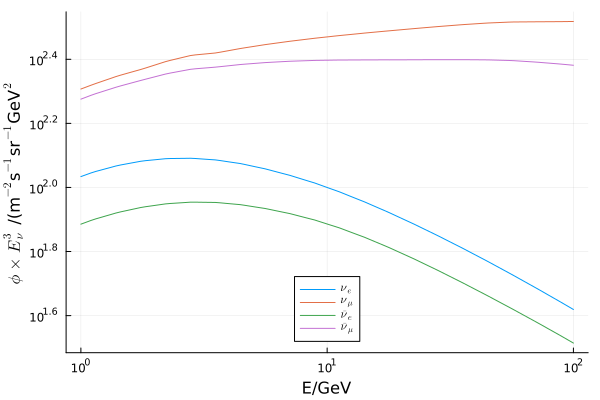

In [17]:
# neutrino fluxes look good
# (comparing with Figure 3 in arXiv:1502.03916;
# there are slight differences, especially at low energies, because
# daemonflux is a bit different from honda)

numberEnergyBinSegments = numberEnergyBins - 1 

p1 = plot(energies, (energies.^3) .* sum(flux_νe,     dims=2) ./ numberEnergyBinSegments, label=L"$\nu_e$", 
          xaxis=:log, yaxis=:log, legend=:bottom,
          xlabel="E/GeV", ylabel=L"$\phi \times E_\nu^3$ /(m$^{-2}$s$^{-1}$sr$^{-1}$GeV$^{2}$")
plot!(p1, energies, (energies.^3) .* sum(flux_νμ,     dims=2) ./ numberEnergyBinSegments, label=L"$\nu_\mu$")
plot!(p1, energies, (energies.^3) .* sum(flux_antiνe, dims=2) ./ numberEnergyBinSegments, label=L"$\bar{\nu}_e$")
plot!(p1, energies, (energies.^3) .* sum(flux_antiνμ, dims=2) ./ numberEnergyBinSegments, label=L"$\bar{\nu}_\mu$")


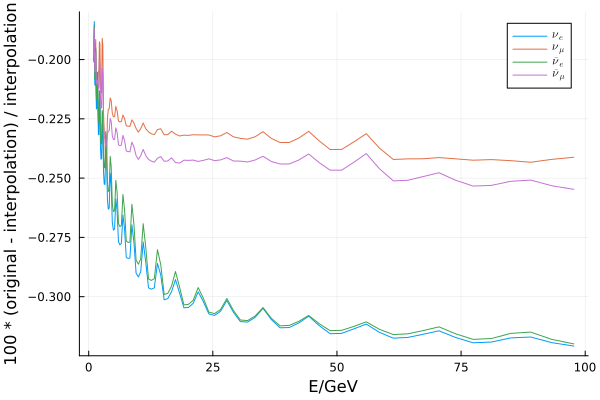

In [18]:

# plot the differences between the original and the interpolated fluxes
# to make sure that the interpolation is working correctly
# -> for the original flux we take the mean values
flux_νe_original     = 0.5 .* (sum(flux_νe,     dims=2)[1:end-1] .+ sum(flux_νe, dims=2)[2:end])
flux_νμ_original     = 0.5 .* (sum(flux_νμ,     dims=2)[1:end-1] .+ sum(flux_νμ, dims=2)[2:end])
flux_antiνe_original = 0.5 .* (sum(flux_antiνe, dims=2)[1:end-1] .+ sum(flux_antiνe, dims=2)[2:end])
flux_antiνμ_original = 0.5 .* (sum(flux_antiνμ, dims=2)[1:end-1] .+ sum(flux_antiνμ, dims=2)[2:end])
p2 = plot(bin_centers, 100 .* (sum(flux_νe_interp, dims=2) .- flux_νe_original) ./ flux_νe_original, 
          label=L"$\nu_e$", xlabel="E/GeV", ylabel="100 * (original - interpolation) / interpolation")
plot!(p2, bin_centers, 100 .* (sum(flux_νμ_interp,     dims=2) .- flux_νμ_original)     ./ flux_νμ_original,     label=L"$\nu_\mu$") 
plot!(p2, bin_centers, 100 .* (sum(flux_antiνe_interp, dims=2) .- flux_antiνe_original) ./ flux_antiνe_original, label=L"$\bar{\nu}_e$") 
plot!(p2, bin_centers, 100 .* (sum(flux_antiνμ_interp, dims=2) .- flux_antiνμ_original) ./ flux_antiνμ_original, label=L"$\bar{\nu}_\mu$") 
